# Notebook 02 - Feature Extraction & Feature-Level EDA

In this notebook, it shows converting each WAV file into a fixed-length 112-dimensiona feature vector using feature.py, and saving the features matrix to csv file, the explore how the features differ across emotions.

**Output:** `features/features.csv` - used by every modeling notebook from now on.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ser.feature import extract_dataset_features, get_feature_names

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\rbk55\OneDrive\Documents\Project_CSE432-532\SER_Project


In [2]:
meta = pd.read_csv(PROJECT_ROOT / "features" / "metadata.csv")
print(f"Loaded {len(meta)} files from metadata.")
meta.head(3)

Loaded 2452 files from metadata.


,filename,modality,channel,emotion,emotion_code,intensity,statement,repetition,actor,gender,path
0,03-02-01-01-01-01-01.wav,audio-only,song,neutral,1,normal,Kids are talking by the door,1,1,male,C:\Users\rbk55\OneDrive\Documents\Project_CSE4...
1,03-02-01-01-01-02-01.wav,audio-only,song,neutral,1,normal,Kids are talking by the door,2,1,male,C:\Users\rbk55\OneDrive\Documents\Project_CSE4...
2,03-02-01-01-02-01-01.wav,audio-only,song,neutral,1,normal,Dogs are sitting by the door,1,1,male,C:\Users\rbk55\OneDrive\Documents\Project_CSE4...


## Run extraction on the full dataset
This loop will go over all the files and extract 112 feature each, and save the results into features/features.csv.
Each row of the output is one audio file with its metadata_features

In [3]:
FEATURES_CSV = PROJECT_ROOT / "features" / "features.csv"

feats = extract_dataset_features(meta, output_csv=FEATURES_CSV)

print(f"\nFinal shape: {feats.shape}")
print(f"Columns: {feats.shape[1]} = {len(meta.columns)} metadata + {feats.shape[1] - len(meta.columns)} features")

Extracting features: 100%|██████████| 2452/2452 [01:05<00:00, 37.30it/s]


Saved 2452 rows × 123 cols to c:\Users\rbk55\OneDrive\Documents\Project_CSE432-532\SER_Project\features\features.csv

Final shape: (2452, 123)
Columns: 123 = 11 metadata + 112 features


### Here doing a sanity check to check the features extracted correct

In [4]:
feature_cols = get_feature_names()

print(f"Total rows: {len(feats)}")
print(f"Rows with any NaN feature: {feats[feature_cols].isna().any(axis=1).sum()}")
print(f"\nFeature value ranges (first 5 features):")
print(feats[feature_cols[:5]].describe().T[["min", "mean", "max", "std"]])

Total rows: 2452
Rows with any NaN feature: 0

Feature value ranges (first 5 features):
                   min        mean         max        std
mfcc1_mean -752.288635 -419.925310 -134.443726  98.471576
mfcc2_mean  -13.112365   76.412558  142.470779  26.516728
mfcc3_mean  -96.421852  -20.172307   33.645687  19.875071
mfcc4_mean  -46.709778    8.307304   42.299503  12.059772
mfcc5_mean  -44.032436   -6.750298   32.547527  14.402968


## How do features differ by emotion?

To continue in training the models, I need first confirm that emotions actually look
different in feature space. If they don't, classifier will be hard to be helpful

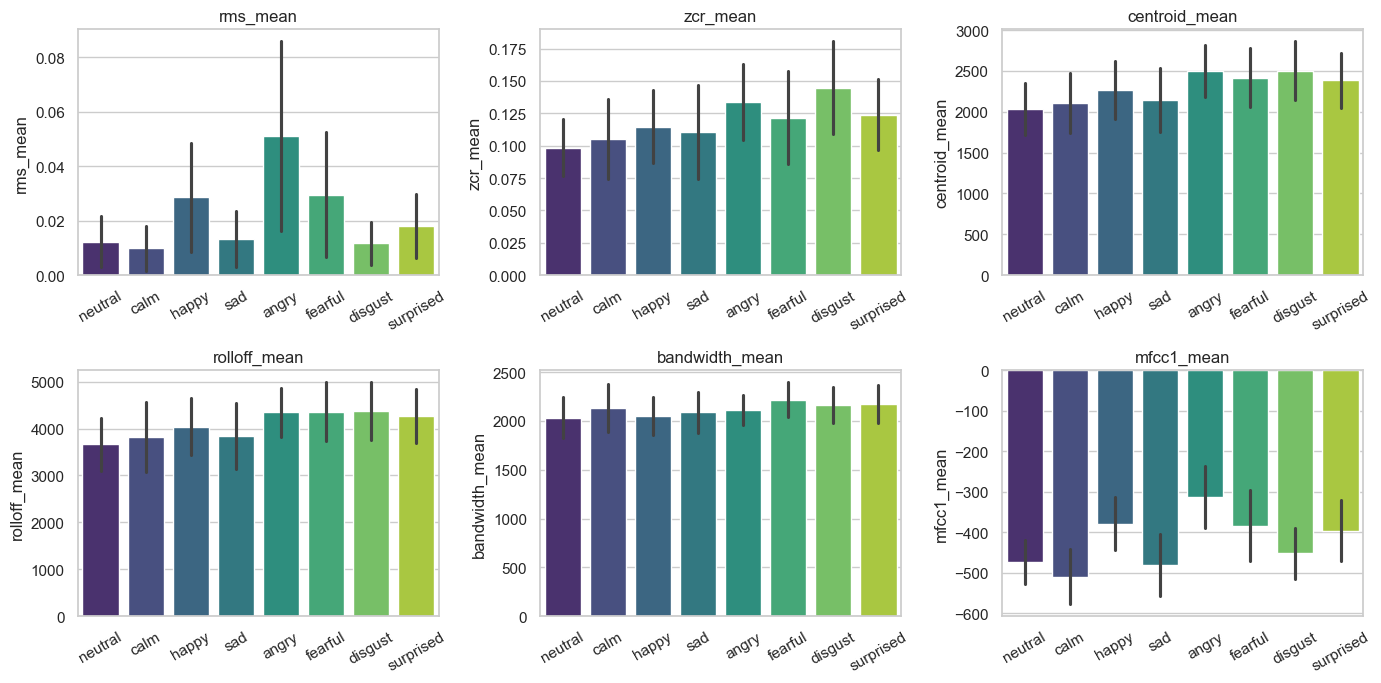

In [5]:
emotion_order = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]
key_features = ["rms_mean", "zcr_mean", "centroid_mean", "rolloff_mean",
                "bandwidth_mean", "mfcc1_mean"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, key_features):
    sns.barplot(data=feats, x="emotion", y=feat, order=emotion_order,
                hue="emotion", palette="viridis", legend=False,
                errorbar="sd", ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "feature_means_by_emotion.png", dpi=120)
plt.show()

**Observation.** RMS is the strongest single discriminator, angry stands out clearly, with happy and fearful elevated, while calm, neutral, and sad sit at the bottom. Centroid, rolloff, and MFCC1 show a consistent high-arousal vs low-arousal split (neutral/calm lowest, angry/disgust/fearful highest), and ZCR increases gradually across emotions. Bandwidth is nearly flat on its mean alone. The wide error bars indicate substantial within-class overlap, so no single feature classifies well in isolation, classifiers will need to combine them.


### Feature correlation

Now will check the correlation, if there is a high correlation it could indcicate a high information redundecny, heavy correlation also could hurt some models

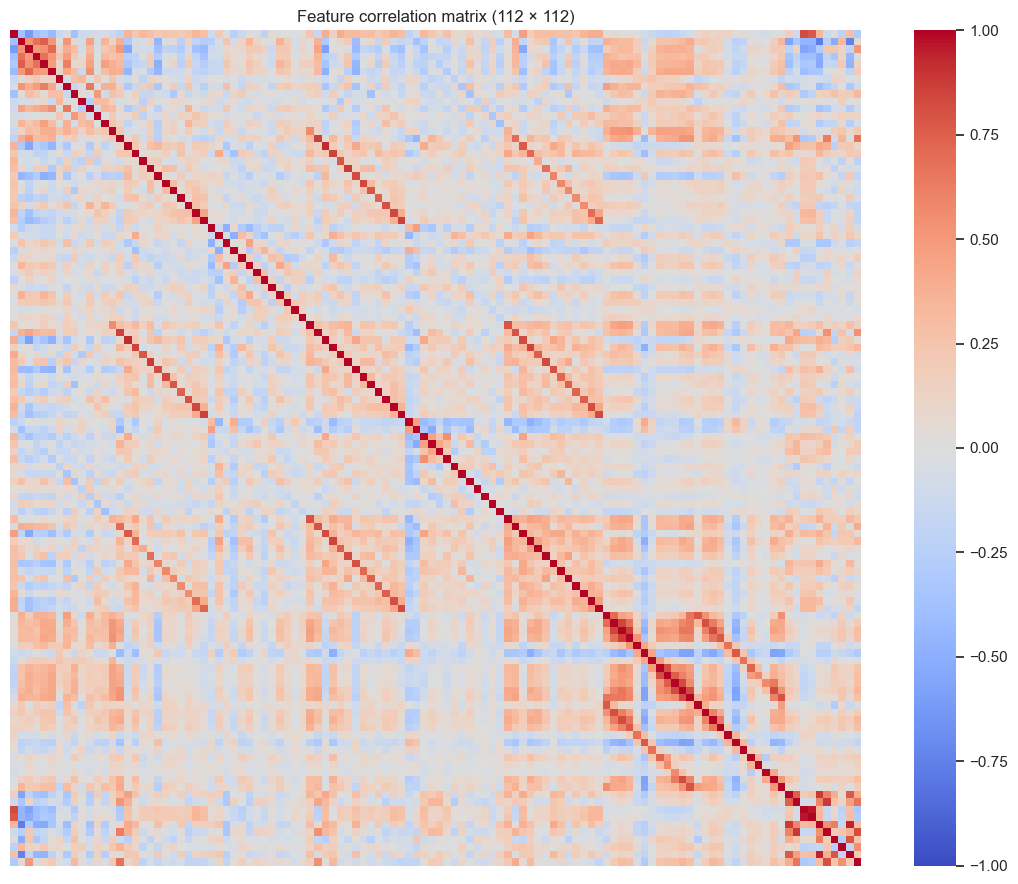

Feature pairs with |correlation| > 0.9: 3


In [6]:
corr = feats[feature_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title("Feature correlation matrix (112 × 112)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "feature_correlation.png", dpi=120)
plt.show()

# Quantify how much redundancy is present
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (upper.abs() > 0.9).sum().sum()
print(f"Feature pairs with |correlation| > 0.9: {high_corr_pairs}")

**Observation.** The heatmap shows clear redundancy in the features. The MFCC blocks (top-left) have diagonal stripes - the same coefficient repeats across MFCC, ΔMFCC, and Δ²MFCC because the deltas are derived from MFCCs. The scalar features (bottom-right) are also strongly correlated with each other, since centroid, rolloff, and bandwidth all describe spectral shape. Chroma stays mostly independent. This redundancy is what PCA will exploit later - we can compress 112 features into many fewer without losing much information.

## Distribution shape per emotion

Now will show Boxplots to show distribution of each feature per emotion, including outliers.
This can tell whether the means that were plotted above are robust or driven by a few extreme files

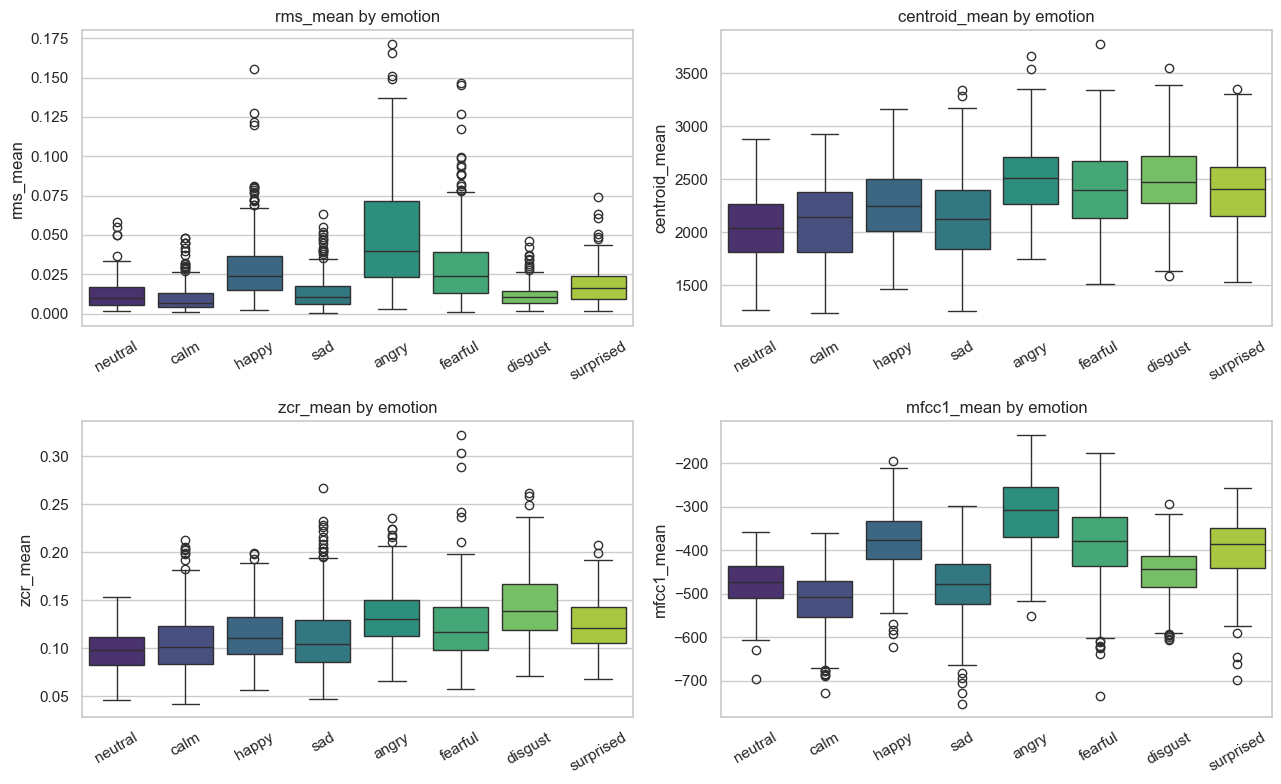

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_features = ["rms_mean", "centroid_mean", "zcr_mean", "mfcc1_mean"]

for ax, feat in zip(axes.flat, plot_features):
    sns.boxplot(data=feats, x="emotion", y=feat, order=emotion_order,
                hue="emotion", palette="viridis", legend=False, ax=ax)
    ax.set_title(f"{feat} by emotion")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "feature_boxplots.png", dpi=120)
plt.show()

**Observation.** Angry has the most distinctive distribution, its RMS, centroid, and MFCC1 medians are clearly separated from the rest. However, the boxes overlap heavily for many other pairs: neutral and calm are nearly indistinguishable, sad behaves like a low-arousal emotion, and angry/fearful/disgust cluster together on the high-arousal side. The outliers and overlapping IQRs suggest classifiers will struggle most with distinguishing similar-arousal emotions (calm vs neutral, angry vs fearful), a pattern we'll likely see in the confusion matrices later.

## Note on standardization

Features live on very different scales (MFCCs in tens, RMS near zero, centroid
in thousands). Distance-based models (kNN, SVM with RBF) and gradient-based
models (logistic regression, neural nets) need standardized inputs.

**We do NOT standardize here.** Doing so on the full dataset would leak test-set
information into our preprocessing. Standardization happens *inside* each
modeling notebook, fit only on the training fold and applied to the test fold.
This is enforced by `minilearn.preprocessing.StandardScaler` (built next).

## Feature Extraction - Summary

- **Output:** `features/features.csv` - 2,452 rows × 112 features + metadata.
- **Per-emotion means** show clear separation on energy and spectral features
  (high-arousal vs low-arousal emotions).
- **Correlation heatmap** reveals strong block-correlations within MFCC groups,
  motivating PCA in a later notebook.
- **Boxplots** confirm that emotion-level means are robust (not driven by
  outliers) for the key features.
- **Standardization is deliberately deferred** to the modeling notebooks to
  avoid data leakage.

### A smoke test for the standarized and split the data

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
from minilearn.preprocessing import StandardScaler, train_test_split

# --- Test StandardScaler ---
np.random.seed(0)
X = np.array([[1, 100], [2, 200], [3, 300], [4, 400]], dtype=float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original X:\n", X)
print("\nMean per column:", scaler.mean_)
print("Std per column:", scaler.std_)
print("\nScaled X:\n", X_scaled)
print("\nVerify: scaled mean ≈ 0:", X_scaled.mean(axis=0).round(6))
print("Verify: scaled std ≈ 1:", X_scaled.std(axis=0).round(6))

# --- Test stratified split ---
y = np.array([0]*30 + [1]*15 + [2]*5)  # imbalanced
X = np.random.randn(50, 3)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)
print(f"\nOriginal class counts: {np.bincount(y)}")
print(f"Train class counts:    {np.bincount(y_tr)}")
print(f"Test class counts:     {np.bincount(y_te)}")
print(f"Train shape: {X_tr.shape}, Test shape: {X_te.shape}")

Original X:
 [[  1. 100.]
 [  2. 200.]
 [  3. 300.]
 [  4. 400.]]

Mean per column: [  2.5 250. ]
Std per column: [  1.11803399 111.80339887]

Scaled X:
 [[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]

Verify: scaled mean ≈ 0: [0. 0.]
Verify: scaled std ≈ 1: [1. 1.]

Original class counts: [30 15  5]
Train class counts:    [24 12  4]
Test class counts:     [6 3 1]
Train shape: (40, 3), Test shape: (10, 3)


### Here I would like to test the metrics that been made

In [3]:
import numpy as np
from sklearn.metrics import (accuracy_score as sk_acc,
                             confusion_matrix as sk_cm,
                             f1_score as sk_f1,
                             roc_auc_score as sk_auc)

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from minilearn.metrics import (accuracy_score, confusion_matrix,
                                f1_score, roc_auc_score,
                                classification_report)


np.random.seed(0)
y_true = np.random.randint(0, 4, size=200)         # 4 classes
y_pred = y_true.copy()
flip = np.random.rand(200) < 0.3                    # introduce 30% errors
y_pred[flip] = (y_pred[flip] + 1) % 4

print(f"Our accuracy:     {accuracy_score(y_true, y_pred):.4f}")
print(f"sklearn accuracy: {sk_acc(y_true, y_pred):.4f}")

print(f"\nOur macro F1:     {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"sklearn macro F1: {sk_f1(y_true, y_pred, average='macro'):.4f}")

print(f"\nOur confusion matrix:\n{confusion_matrix(y_true, y_pred)}")
print(f"\nsklearn confusion matrix:\n{sk_cm(y_true, y_pred)}")

# --- AUC test (multiclass one-vs-rest) ---
y_score = np.zeros((200, 4))
for i, c in enumerate(y_true):
    y_score[i, c] = 0.7 + 0.3 * np.random.rand()
    y_score[i, [j for j in range(4) if j != c]] = 0.3 * np.random.rand(3)
y_score = y_score / y_score.sum(axis=1, keepdims=True)

print(f"\nOur AUC (macro):     {roc_auc_score(y_true, y_score, average='macro'):.4f}")
print(f"sklearn AUC (macro): {sk_auc(y_true, y_score, multi_class='ovr', average='macro'):.4f}")

# --- Classification report ---
print("\n--- Classification report ---")
print(classification_report(y_true, y_pred,
                             label_names=["A", "B", "C", "D"]))

Our accuracy:     0.7000
sklearn accuracy: 0.7000

Our macro F1:     0.6976
sklearn macro F1: 0.6976

Our confusion matrix:
[[37 14  0  0]
 [ 0 28 14  0]
 [ 0  0 33 15]
 [17  0  0 42]]

sklearn confusion matrix:
[[37 14  0  0]
 [ 0 28 14  0]
 [ 0  0 33 15]
 [17  0  0 42]]

Our AUC (macro):     1.0000
sklearn AUC (macro): 1.0000

--- Classification report ---
class            precision     recall         f1    support
------------------------------------------------------------
A                    0.685      0.725      0.705         51
B                    0.667      0.667      0.667         42
C                    0.702      0.688      0.695         48
D                    0.737      0.712      0.724         59
------------------------------------------------------------
macro avg            0.698      0.698      0.698        200
weighted avg         0.701      0.700      0.700        200
accuracy             0.700
